In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/food_delivery_featured.csv")

df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_Orderd,Time_Order_picked,...,City,Time_taken(min),Delivery_Distance_km,Preparation_Time,Order_Hour,Pickup_Hour,Peak_Hour,Driver_Category,Age_Group,Distance_Category
0,0x4607_x,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,1900-01-01 11:30:00,1900-01-01 11:45:00,...,3,24.0,3.025149,15.0,11,11,0,Excellent,36-45,Medium
1,0xb379_x,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,1900-01-01 19:45:00,1900-01-01 19:50:00,...,1,33.0,20.183530,5.0,19,19,1,Good,26-35,Very Long
2,0x20f7_x,BANGRES18DEL01,37,4.4,12.913041,77.683237,12.953041,77.723237,1900-01-01 13:50:00,1900-01-01 13:55:00,...,1,42.0,6.210864,5.0,13,13,0,Average,36-45,Long
3,0x7804_x,HYDRES13DEL02,28,4.9,17.431477,78.400350,17.451477,78.420350,1900-01-01 11:00:00,1900-01-01 11:15:00,...,3,19.0,3.073618,15.0,11,11,0,Excellent,26-35,Medium
4,0x7faf_x,RANCHIRES07DEL01,37,4.6,23.359407,85.325055,23.429407,85.395055,1900-01-01 23:50:00,1900-01-01 00:00:00,...,1,25.0,10.564974,10.0,23,0,0,Good,36-45,Very Long


In [2]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Time_Orderd', 'Time_Order_picked',
       'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition',
       'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival',
       'City', 'Time_taken(min)', 'Delivery_Distance_km', 'Preparation_Time',
       'Order_Hour', 'Pickup_Hour', 'Peak_Hour', 'Driver_Category',
       'Age_Group', 'Distance_Category'],
      dtype='str')

In [2]:
drop_cols = [
    "ID",
    "Delivery_person_ID",
    "Time_Orderd",
    "Time_Order_picked"
]

df = df.drop(columns=drop_cols)

In [3]:
df = pd.get_dummies(
    df,
    columns=[
        "Driver_Category",
        "Age_Group",
        "Distance_Category"
    ],
    drop_first=True
)

In [4]:
X = df.drop("Time_taken(min)", axis=1)

y = df["Time_taken(min)"]

In [5]:
missing = X.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
print("y_test exists:", "y_test" in locals())

y_test exists: True


In [9]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1881, 26)
(471, 26)
(1881,)
(471,)


In [10]:
print(X_train.dtypes)

Delivery_person_Age              int64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Weatherconditions                int64
Road_traffic_density             int64
Vehicle_condition                int64
Type_of_order                    int64
Type_of_vehicle                  int64
multiple_deliveries            float64
Festival                         int64
City                             int64
Delivery_Distance_km           float64
Preparation_Time               float64
Order_Hour                       int64
Pickup_Hour                      int64
Peak_Hour                        int64
Driver_Category_Excellent         bool
Driver_Category_Good              bool
Age_Group_26-35                   bool
Age_Group_36-45                   bool
Distance_Category_Medium          bool
Distance_Category_Short           bool
Distance_Category_Very Lo

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

In [10]:
print("pred_lr exists:", "pred_lr" in locals())

pred_lr exists: True


In [11]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [13]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [14]:
print(id(globals()))

X = df.drop("Time_taken(min)", axis=1)
y = df["Time_taken(min)"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("After split:")
print("y_test exists:", "y_test" in locals())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print("pred_lr exists:", "pred_lr" in locals())
print("Length:", len(pred_lr))

1982447577152
After split:
y_test exists: True
pred_lr exists: True
Length: 471


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2  :", r2_score(y_test, pred_lr))

MAE : 5.118630008351771
RMSE: 6.477747216961345
R2  : 0.5332015870682167


Model Evaluation

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



def evaluate(y_true, pred):
    print("MAE :", mean_absolute_error(y_true, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, pred)))
    print("R²  :", r2_score(y_true, pred))

In [18]:
evaluate(y_test, pred_lr)

evaluate(y_test, pred_dt)

evaluate(y_test, pred_rf)

evaluate(y_test, pred_xgb)

MAE : 5.118630008351771
RMSE: 6.477747216961345
R²  : 0.5332015870682167
MAE : 4.479830148619958
RMSE: 5.713989983248345
R²  : 0.6367878838329083
MAE : 3.6046709129511676
RMSE: 4.497694077745299
R²  : 0.7749592311607583
MAE : 3.771129002743213
RMSE: 4.774159500784709
R²  : 0.7464432207006345


In [19]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(10))

                        Feature  Importance
1       Delivery_person_Ratings    0.247956
6             Weatherconditions    0.116182
11          multiple_deliveries    0.101320
7          Road_traffic_density    0.098837
14         Delivery_Distance_km    0.090961
0           Delivery_person_Age    0.078391
8             Vehicle_condition    0.073338
25  Distance_Category_Very Long    0.036899
16                   Order_Hour    0.032277
4    Delivery_location_latitude    0.016782


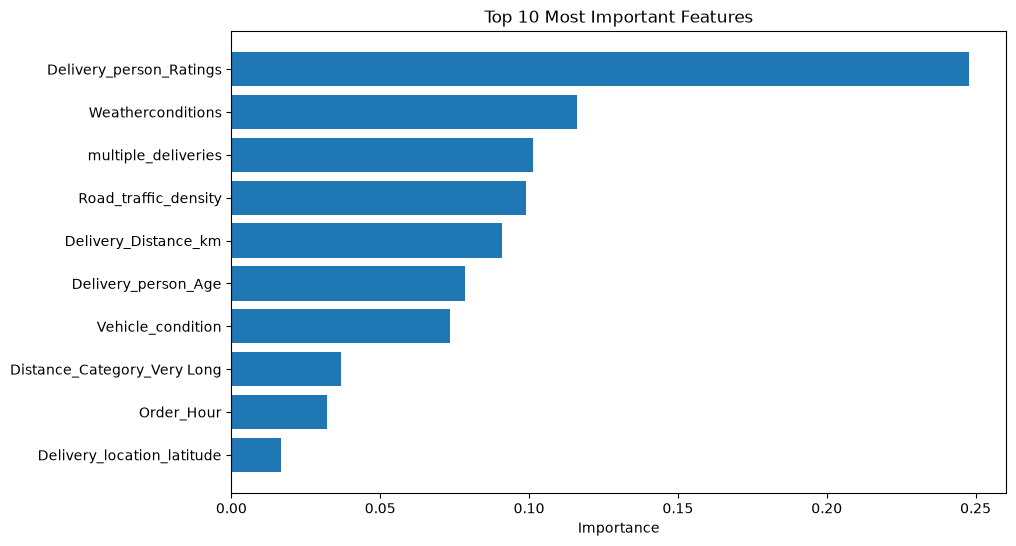

In [20]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.xlabel("Importance")

plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

In [21]:
import joblib

joblib.dump(rf, "food_delivery_model.pkl")

['food_delivery_model.pkl']